In [1]:
import openseespy.opensees as ops
import matplotlib.pyplot as plt
import opsvis as opsv  # for visualization
import numpy as np
import pandas as pd
import json
import os
from IPython.display import clear_output

from sections import *
from units import *
from utilities import *
from modelBuilder import *

# Add latex fonts for plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

RSN2972


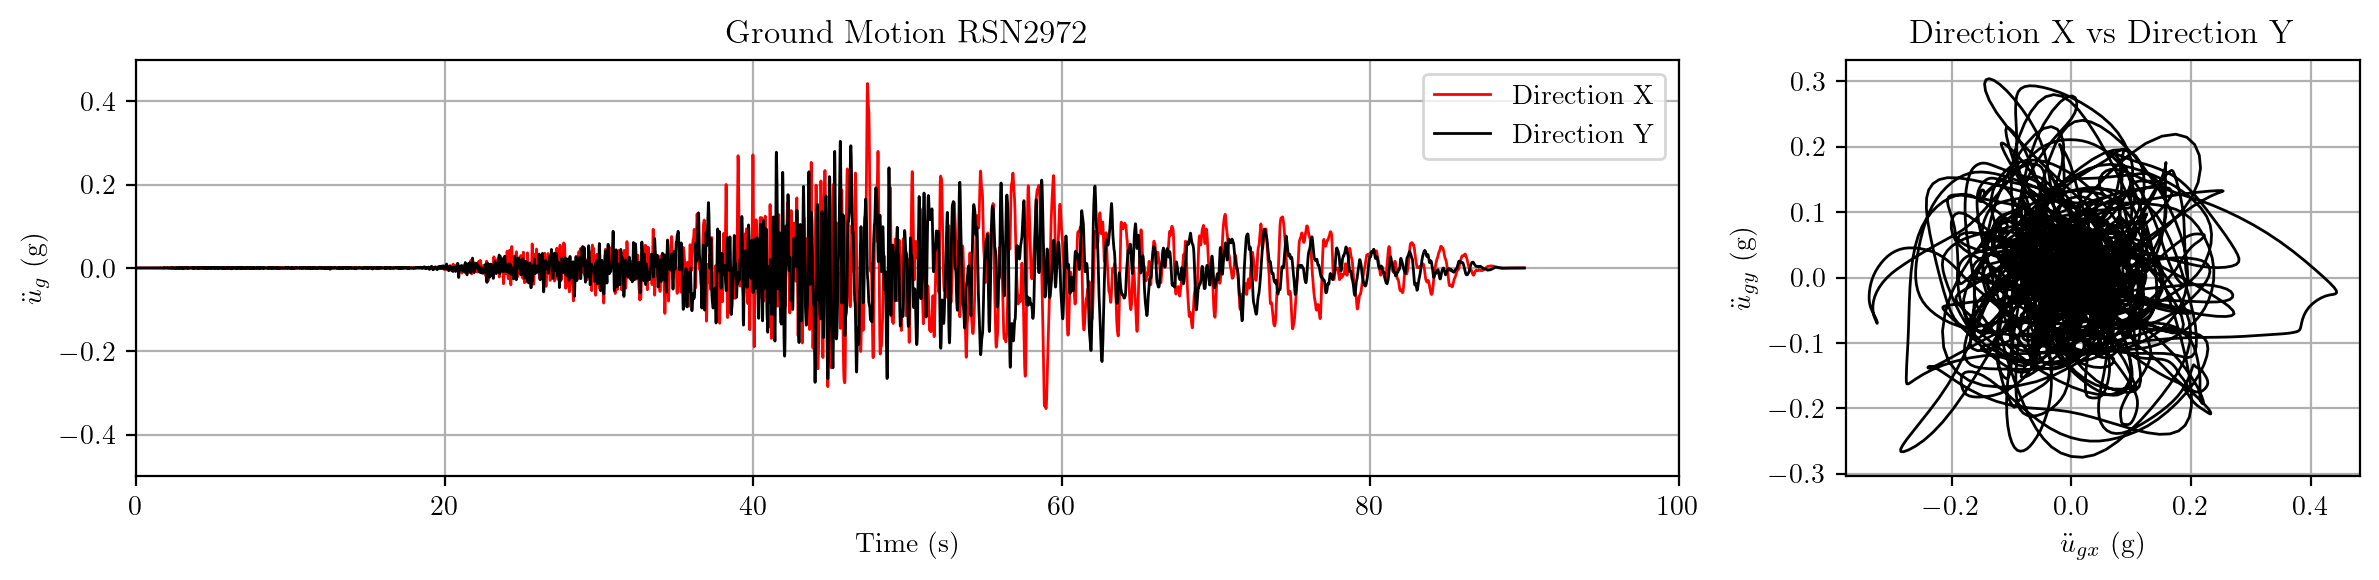

In [2]:
# Select GM
selGM = 0

# Create output folder for selected GM
out_folder = f'out_gm{selGM}'
if not os.path.exists(out_folder):
    os.makedirs(out_folder)

# Select direction of GM (now useless, cuz both directions are applied)
 
# Open Ground Motion Data
cd = os.getcwd()
gmTable = pd.read_csv("gms//site0.csv")

gmCode = str(selGM).zfill(2)

g = 386

sf = gmTable["factor"][selGM]*5.0

print(gmTable["TH_file"][selGM])

with open(cd+"//gms//"+gmTable["TH_file"][selGM]+".json") as file:
    gm_data = json.load(file)
    
gmx = np.array(gm_data["data_x"]) * g * sf
gmy = np.array(gm_data["data_y"]) * g * sf
dt = float(gm_data["dT"])
# print("dt =", dt)

gmx = gmx[0:-1:1]
gmy = gmy[0:-1:1]

t = np.arange(0, dt * len(gmx), dt)

# Create subplots with 3:1 width ratio (3/4 left, 1/4 right)
fig, axs = plt.subplots(1, 2, figsize=(12, 3), dpi=200, gridspec_kw={'width_ratios': [3, 1]})

# Left subplot: time histories
axs[0].plot(t, gmx/g, 'r', linewidth=1.0, label='Direction X')
axs[0].plot(t, gmy/g, 'k', linewidth=1.0, label='Direction Y')
axs[0].grid()
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('$\\ddot{u}_g$ (g)')
axs[0].set_xlim([0, 10 * np.round(max(t) / 10 + 1)])
pga = np.round(np.max(np.abs([gmx, gmy])) / g, 2)
ylim_val = np.ceil(10 * pga) / 10
axs[0].set_ylim([-ylim_val, ylim_val])
axs[0].set_title('Ground Motion ' + gmTable["TH_file"][selGM])
axs[0].legend()

# Right subplot: gmx vs gmy
axs[1].plot(gmx/g, gmy/g, color='k', linewidth=1.0)
axs[1].set_xlabel('$\ddot{u}_{gx}$ (g)')
axs[1].set_ylabel('$\ddot{u}_{gy}$ (g)')
axs[1].set_title('Direction X vs Direction Y')
axs[1].grid()

plt.tight_layout()

# Save to the corresponding out_gmx folder

plt.savefig(os.path.join(out_folder, f'GM_{gmCode}_plot.png'))

Periods of identified modes: [0.39576239 0.34357561 0.3434901  0.32967996 0.32114733 0.30939216
 0.30338416 0.30208217 0.29805288 0.28743399]


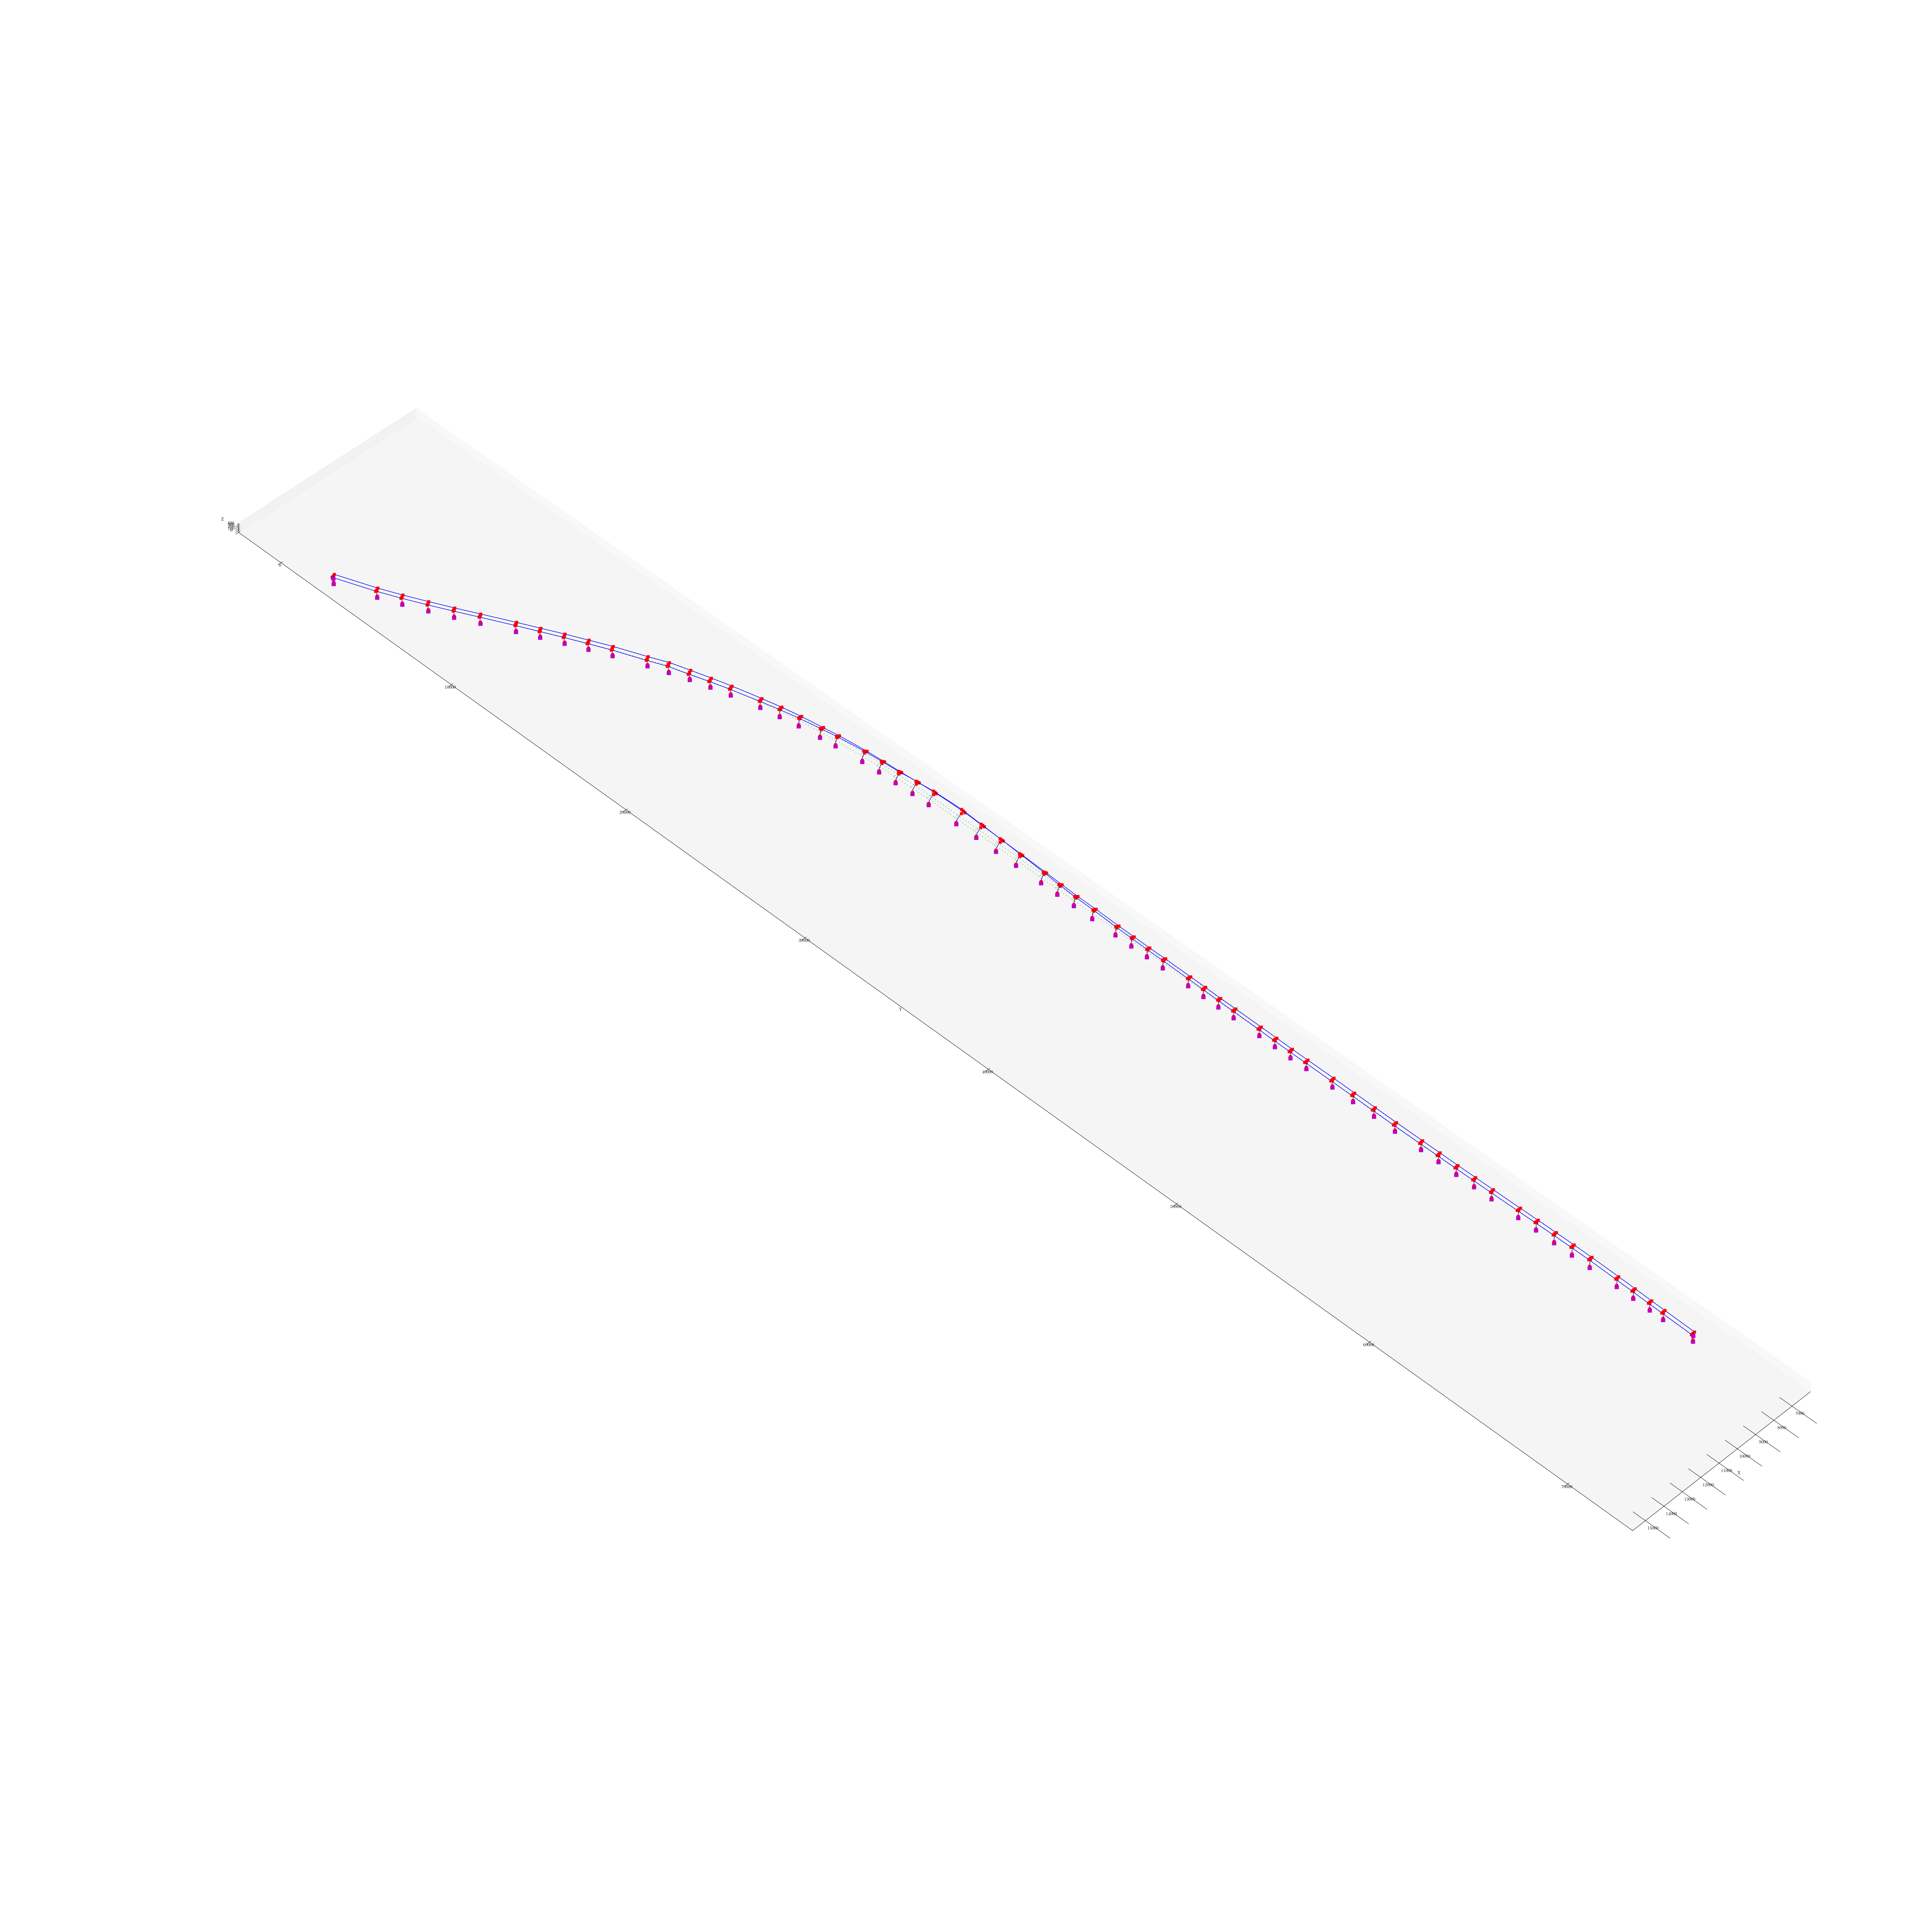

In [3]:
# Load excel file with model geometry
nodes_df = pd.read_excel("model_geometry.xlsx", sheet_name="nodeInfo")
elements_df = pd.read_excel("model_geometry.xlsx", sheet_name="elements")

# Generate Model
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)  # frame 3D

getSections(plot=False)
buildModel(nodes_df, elements_df)

# Run Eigenvalue Analysis

# Perform an eigenvalue analysis
numEigen = 10
eigenValues = ops.eigen(numEigen)
# print("eigen values at start of transient:",eigenValues)
T = 2 * np.pi / np.sqrt(np.array(eigenValues))
print('Periods of identified modes:', T)

# Uncomment to show mode shape
opsv.plot_mode_shape(5, fig_wi_he=(200., 200.), sfac=-1000.0)
ax = plt.gca()
ax.view_init(elev=45, azim=45)  # tilt up/down, rotate around
ax.grid(False)
plt.show()
# plt.savefig(os.path.join(out_folder, f'ModeShape_mode2_gm{gmCode}.png'))

# Uncomment to plot model
# opsv.plot_model(fig_wi_he=(400., 280.), node_labels=0, element_labels=0, local_axes=0, gauss_points=0)
# plt.savefig("model.pdf")
ops.wipeAnalysis()

In [4]:
# Print mass matrix
ops.system('FullGeneral')
ops.analysis('Transient')

# Mass
ops.integrator('GimmeMCK', 1.0, 0.0, 0.0)
ops.analyze(1,0.0)

# Number of equations in the model
N = ops.systemSize() # Has to be done after analyze
print(f'Number of equations in the model: {N}')

M = ops.printA('-ret') # Or use ops.printA('-file','M.out')
# M = np.array(M).reshape(N, N) # Convert the list to an array
# M.shape = (N,N) # Make the array an NxN matrix

count = 0
trans_mass_x = 0.0
trans_mass_y = 0.0
trans_mass_z = 0.0
rot_mass_x = 0.0
rot_mass_y = 0.0
rot_mass_z = 0.0

for val in M:
    if val<0:
        print(f'Negative mass detected at dof {count}, value={val}')
    # Assume dofs are ordered as [ux1, uy1, uz1, rx1, ry1, rz1, ux2, uy2, ...]
    # Sum translational mass (ux, uy, uz) only (separately)
    if count % 6 == 0:
        trans_mass_x += val
    elif count % 6 == 1:
        trans_mass_y += val
    elif count % 6 == 2:   
        trans_mass_z += val
    elif count % 6 == 3:
        rot_mass_x += val
    elif count % 6 == 4:
        rot_mass_y += val
    elif count % 6 == 5:
        rot_mass_z += val
    count += 1

print(f'Translational mass in X direction: {trans_mass_x*386:.2f} kips-s^2/in')
print(f'Translational mass in Y direction: {trans_mass_y*386:.2f} kips-s^2/in')
print(f'Translational mass in Z direction: {trans_mass_z*386:.2f} kips-s^2/in')
print(trans_mass_x/65*386)

WARNING analysis Transient - no Algorithm yet specified, 
 NewtonRaphson default will be used
WARNING analysis Transient - no ConstraintHandler yet specified, 
 PlainHandler default will be used
WARNING analysis Transient - no Numberer specified, 
 RCM default will be used
WARNING analysis Transient - no Integrator specified, 
 TransientIntegrator default will be used
WARNING PlainHandler::handle() -  constraint matrix not identity, ignoring constraint for node 21
 non-varyng assumed
WARNING PlainHandler::handle() -  constraint matrix not identity, ignoring constraint for node 121
 non-varyng assumed
WARNING PlainHandler::handle() -  constraint matrix not identity, ignoring constraint for node 221
 non-varyng assumed
WARNING PlainHandler::handle() -  constraint matrix not identity, ignoring constraint for node 321
 non-varyng assumed
WARNING PlainHandler::handle() -  constraint matrix not identity, ignoring constraint for node 421
 non-varyng assumed
WARNING PlainHandler::handle() -  c

Number of equations in the model: 1560
Translational mass in X direction: 20859.01 kips-s^2/in
Translational mass in Y direction: 20859.01 kips-s^2/in
Translational mass in Z direction: 20859.01 kips-s^2/in
320.9078607302769


In [ ]:
# Compute rayleigh damping for 2% damping in first two modes
zeta = 0.02
omega1 = 2 * np.pi / T[0]
omega2 = 2 * np.pi / T[1]

alphaM = 2 * zeta * omega1 * omega2 / (omega1 + omega2)
betaK = 2 * zeta / (omega1 + omega2)

# Add Rayleigh Damping
ops.rayleigh(alphaM, 0.0, betaK, 0.0)

In [10]:
nodes_df


,nodeID,X,Y,Z,desc
0,10,14982.044900,2332.912700,0.0,base
1,110,14304.670000,4154.576800,0.0,base
2,210,13867.809500,5164.909400,0.0,base
3,310,13397.980900,6174.734900,0.0,base
4,410,12914.040800,7168.044700,0.0,base
...,...,...,...,...,...
322,6022,7167.867944,64531.515957,410.4,top east
323,6122,7173.433731,65369.967027,397.2,top east
324,6222,7182.177285,66202.347418,379.2,top east
325,6322,7190.690488,66891.549394,379.2,top east


In [ ]:
# Apply gravity loads

top_of_column_nodes = nodes_df[nodes_df['type']=='column_top']['node_id'].tolist()

In [ ]:
# Create recorders

# print('running analysis for time:', tCurrent)
nodeTags = []
for nodeID in nodes_df[nodes_df["desc"] == "top of beam"]["nodeID"]:
    nodeTags.append(nodeID)

# Recorders for displacements at top
ops.recorder('Node', '-file', os.path.join(out_folder, 'node_disp_x_'+'.out'), '-node', *nodeTags, '-dof', 1, 'disp')
ops.recorder('Node', '-file', os.path.join(out_folder, 'node_disp_y_'+'.out'), '-node', *nodeTags, '-dof', 2, 'disp')

nodeTags = []
for nodeID in nodes_df[nodes_df["desc"] == "base"]["nodeID"]:
    nodeTags.append(nodeID)

ops.recorder('Node', '-file', os.path.join(out_folder, 'base_disp_x_'+'.out'), '-node', *nodeTags, '-dof', 1, 'disp')
ops.recorder('Node', '-file', os.path.join(out_folder, 'base_disp_y_'+'.out'), '-node', *nodeTags, '-dof', 2, 'disp')

3

In [20]:
eleTags = []
for eleID in elements_df[elements_df["type"] == "pierCol"]["eleTag"]:
    eleTags.append(eleID)

# Create one recorder per element
for eleTag in eleTags:
    ops.recorder('Element', '-file', os.path.join(out_folder, f'ele_forces_{eleTag}.out'), '-ele', eleTag, 'force')

print('Element force recorders created')

Element force recorders created


In [21]:
# Create objects for dynamic analysis

# timeSeries('Path', tag, '-dt', dt=0.0, '-values', *values, '-time', *time, '-filePath', filePath='', '-fileTime', fileTime='', '-factor', factor=1.0, '-startTime', startTime=0.0, '-useLast', '-prependZero')
ops.timeSeries('Path', 1, '-dt', dt, '-values', *gmx)
ops.timeSeries('Path', 2, '-dt', dt, '-values', *gmy)

# pattern('UniformExcitation', patternTag, dir, '-disp', dispSeriesTag, '-vel', velSeriesTag, '-accel', accelSeriesTag, '-vel0', vel0, '-fact', fact)
ops.pattern('UniformExcitation', 1, 1, '-accel', 1)
ops.pattern('UniformExcitation', 2, 2, '-accel', 2)

ops.system("BandGeneral")
ops.constraints('Penalty', 1.0, 1.0)
ops.test('NormDispIncr', 1.0e-12,  1)
ops.algorithm("Newton")
ops.numberer('RCM')
ops.integrator('Newmark',  0.5,  0.25)
ops.analysis('Transient')

# set some variables for dynamic analysis
tFinal = len(gmx)*dt
tCurrent = ops.getTime()
ok = 0

time = [tCurrent]
u_top = np.zeros((len(gmx), 65))  # array to store response values (one column per pier)

# Perform the transient analysis
step = 0

u1 = [0.0]

while ok == 0 and tCurrent < tFinal:
    step += 1
    ok = ops.analyze(1, dt)
    
    # if the analysis fails try initial tangent iteration
    if ok != 0:
        print("regular newton failed .. lets try an initial stiffness for this step")
        ops.test('NormDispIncr', 1.0e-12,  100, 0)
        ops.algorithm('ModifiedNewton', '-initial')
        ok = ops.analyze(1, dt)
        
        if ok == 0:
            print("that worked .. back to regular newton")
            
        ops.test('NormDispIncr', 1.0e-12,  10)
        ops.algorithm('Newton')
    
    tCurrent = ops.getTime()
    
    u1.append(ops.nodeDisp(110, 1))  # just to make sure we have the last step recorded
    if tCurrent > 10 and tCurrent < 10 + dt:
        print(tCurrent)
    
    if tCurrent > 25 and tCurrent < 25 + dt:
        print(tCurrent)
        
    if tCurrent > 45 and tCurrent < 45 + dt:
        print(tCurrent)
        
    if tCurrent > 60 and tCurrent < 60 + dt:
        print(tCurrent)
            
    time.append(tCurrent)


regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton


after: 1 iterations  current Norm: 2.00484e-06 (max: 1e-12, Norm deltaR: 6.4438e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 0.005
OpenSees > analyze failed, returned: -3 error flag


10.000000000000163
25.00499999999931
45.00000000000457
60.00000000001224


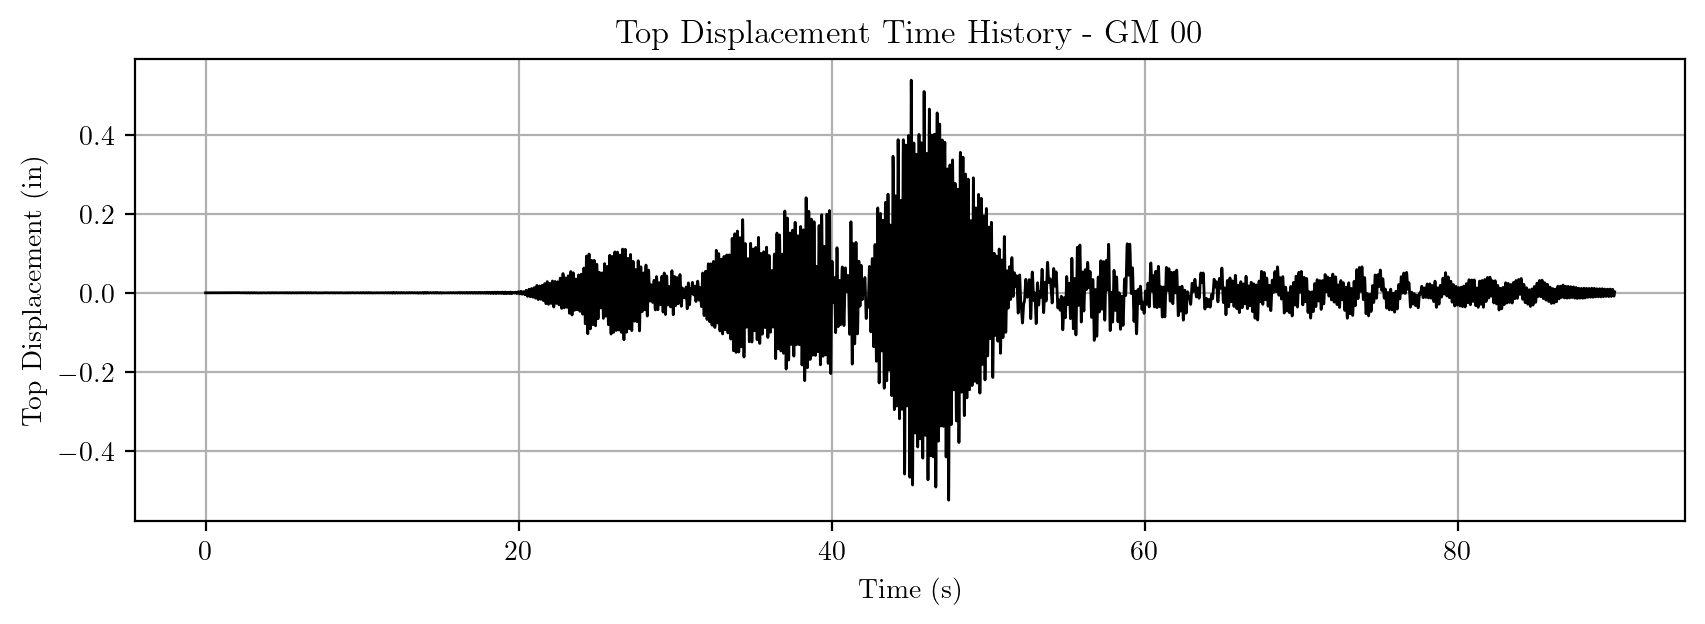

In [26]:
plt.figure(figsize=(10, 3), dpi=200)
plt.plot(time, u1, 'k', linewidth=1.0)
plt.xlabel('Time (s)')
plt.ylabel('Top Displacement (in)')
plt.title('Top Displacement Time History - GM ' + gmCode)
plt.grid()
plt.savefig(os.path.join(out_folder, f'GM_{gmCode}_top_disp_time_history.png'))

In [23]:
ops.nodeDisp(10, 1)  # just to make sure we have the last step recorded

-0.01742921591100124